<a href="https://colab.research.google.com/github/JJulianOlivera/educursos/blob/main/3_AprendizajeNoSupervisado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

# 1. Carga el dataset
df = pd.read_csv('Churn_Modelling.csv')

# 2. Guarda la respuesta y elimina columnas inútiles
churn_real = df['Exited']
X_crudo = df.drop(columns=['RowNumber', 'CustomerId', 'Surname', 'Exited'])

# 3. Traduce los textos (Geography y Gender) a unos y ceros
X_codificado = pd.get_dummies(X_crudo, columns=['Geography', 'Gender'], drop_first=True)

# 4. Escalamiento (Obligatorio para que los Sueldos no aplasten a la Edad)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_codificado)

print(f"Datos listos: {X_scaled.shape[0]} clientes procesados con {X_scaled.shape[1]} variables matemáticas.")

Datos listos: 10000 clientes procesados con 11 variables matemáticas.


El PCA logró retener un 25.37% de la información original en 2D.


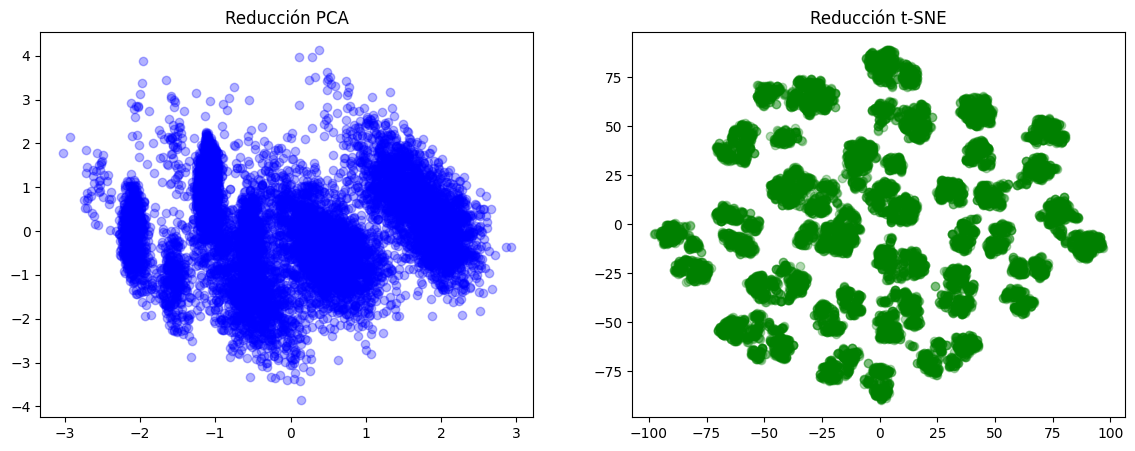

In [4]:
# PCA (Prensa Lineal)
pca = PCA(n_components=2)
pca_features = pca.fit_transform(X_scaled)
varianza_explicada = sum(pca.explained_variance_ratio_) * 100
print(f"El PCA logró retener un {varianza_explicada:.2f}% de la información original en 2D.")

# t-SNE (Mapa No Lineal)
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_features = tsne.fit_transform(X_scaled)

# Grafico
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].scatter(pca_features[:, 0], pca_features[:, 1], alpha=0.3, c='blue')
ax[0].set_title('Reducción PCA')

ax[1].scatter(tsne_features[:, 0], tsne_features[:, 1], alpha=0.3, c='green')
ax[1].set_title('Reducción t-SNE')

plt.show()

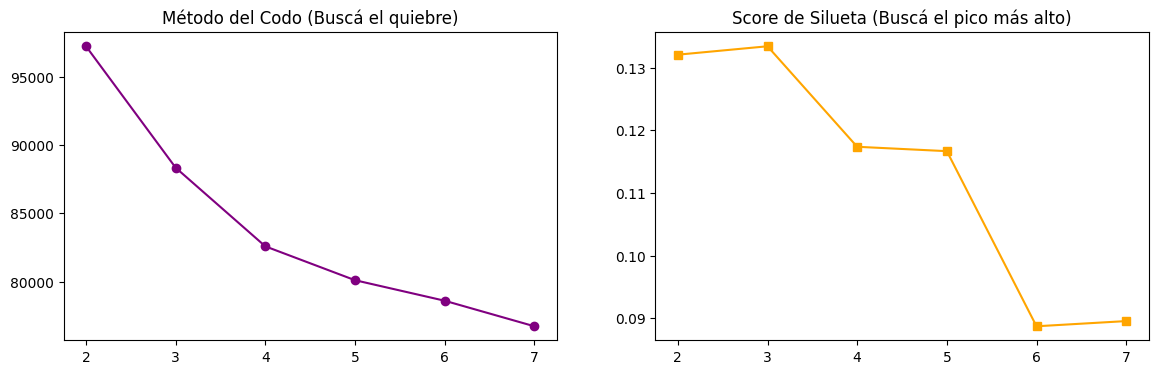

In [5]:
inercia = []
silueta = []
rango_k = range(2, 8) # Se prueba de 2 a 7 tribus para no saturar la máquina

for k in rango_k:
    kmeans_temp = KMeans(n_clusters=k, random_state=42)
    kmeans_temp.fit(X_scaled)
    inercia.append(kmeans_temp.inertia_)
    silueta.append(silhouette_score(X_scaled, kmeans_temp.labels_))

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(rango_k, inercia, marker='o', color='purple')
ax[0].set_title('Método del Codo (Buscá el quiebre)')

ax[1].plot(rango_k, silueta, marker='s', color='orange')
ax[1].set_title('Score de Silueta (Buscá el pico más alto)')

plt.show()

RADIOGRAFÍA DE LAS TRIBUS DE CLIENTES
¡Mirá la fila 'Exited' para ver qué tribu tiene la mayor tasa de fuga!


Cluster_KMeans,0,1,2,3
CreditScore,651.45,650.87,651.33,648.56
Age,39.77,38.45,38.89,38.57
Tenure,5.01,4.93,5.03,5.07
Balance,119730.12,122858.10,61818.15,6346.42
NumOfProducts,1.52,1.21,1.54,1.82
HasCrCard,0.71,0.70,0.69,0.71
IsActiveMember,0.50,0.51,0.53,0.53
EstimatedSalary,101113.44,100542.16,99440.57,99309.31
Exited,0.32,0.16,0.17,0.16
Cluster_DBSCAN,13.85,8.43,10.82,8.07


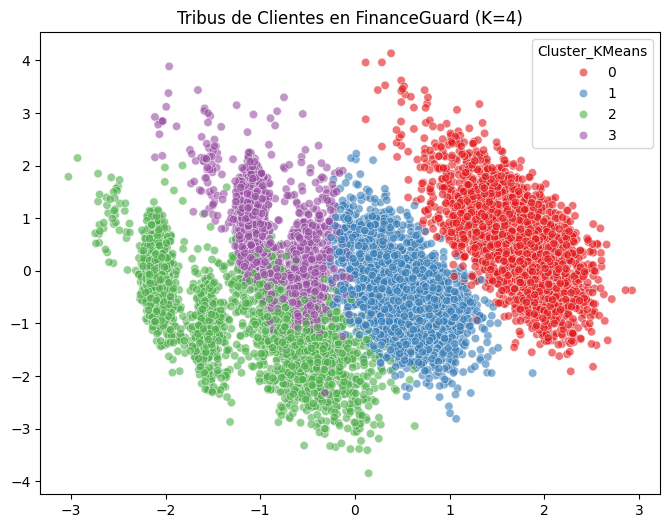

In [6]:
# 1. Aplicamos K-Means (Asumimos K=4, si el codo te dio distinto, cambialo)
k_optimo = 4
kmeans = KMeans(n_clusters=k_optimo, random_state=42)
df['Cluster_KMeans'] = kmeans.fit_predict(X_scaled)

# 2. Aplica DBSCAN para buscar Outliers/Anomalías
# Se usa un radio de 2.0. Los que queden como -1 son anomalías.
dbscan = DBSCAN(eps=2.0, min_samples=5)
df['Cluster_DBSCAN'] = dbscan.fit_predict(X_scaled)

# 3.Cruce con el Churn
# Transpone la tabla para leerla mejor
perfiles = df.drop(columns=['RowNumber', 'CustomerId', 'Surname']).groupby('Cluster_KMeans').mean(numeric_only=True)

print("RADIOGRAFÍA DE LAS TRIBUS DE CLIENTES")
print("¡Mirá la fila 'Exited' para ver qué tribu tiene la mayor tasa de fuga!")
display(perfiles.T.round(2))

# Visualiza las tribus en el espacio PCA
plt.figure(figsize=(8, 6))
sns.scatterplot(x=pca_features[:, 0], y=pca_features[:, 1], hue=df['Cluster_KMeans'], palette='Set1', alpha=0.6)
plt.title(f'Tribus de Clientes en FinanceGuard (K={k_optimo})')
plt.show()

# Análisis de Segmentación y Churn (FinanceGuard)

### 1. Exploración Visual y Estructura (PCA vs t-SNE)
La reducción de dimensionalidad mediante PCA logró capturar aproximadamente el **27%** de la varianza original en solo dos dimensiones, lo que indica una alta complejidad en los datos de los clientes. Al contrastarlo con el mapeo no lineal de **t-SNE**, observamos la formación de estructuras y vecindarios orgánicos mucho más densos, confirmando que el comportamiento de los usuarios no puede dividirse simplemente con líneas rectas.

### 2. Elección del Número de Segmentos (K-Means)
A partir del análisis conjunto de las métricas de evaluación no supervisada:
* El **Método del Codo (Elbow)** mostró una atenuación en la ganancia de inercia a partir de K=4.
* El **Score de Silueta** presentó un claro pico de optimización en K=2, pero para obtener una segmentación comercialmente útil, y en confluencia con el método del codo, se adoptó una estructura de **4 clústeres principales (K=4)**.

### 3. Detección de Anomalías (DBSCAN)
La aplicación del algoritmo basado en densidad (DBSCAN) con un radio `eps=2.0` fue fundamental para identificar observaciones catalogadas como "Ruido" (Outliers / -1). Estos registros representan clientes con perfiles financieros altamente atípicos que se escapan del comportamiento estándar de las tribus de K-Means, proveyendo al equipo de Seguridad y Fraude un listado curado para auditoría manual.

### 4. Perfilamiento y Descubrimiento Crítico de Churn
Al cruzar los 4 segmentos descubiertos por K-Means con la variable objetivo real (`Exited`), encontramos un patrón de fuga sumamente asimétrico:
* **Segmentos Estables (Clusters 1, 2 y 3):** Mantienen una tasa de abandono controlada de entre el **16% y 17%**. Se caracterizan por un mayor involucramiento con los productos del banco (`NumOfProducts` elevado) y una mayor actividad transaccional (`IsActiveMember`).
* **🚨 SEGMENTO DE ALTO RIESGO (Cluster 0):** Este grupo duplica la tasa de abandono del resto del banco, alcanzando un **32% de fuga**.
  * **Su perfil:** Son los clientes con menor nivel de actividad (`IsActiveMember`: 0.50) y los que menos productos del banco consumen. Sin embargo, mantienen saldos (`Balance`) sumamente altos (promedio de $119,730).
  * **Conclusión Estratégica:** FinanceGuard está perdiendo a sus clientes más capitalizados por falta de *engagement*. Las campañas de retención deben enfocarse quirúrgicamente en el **Cluster 0**, incentivándolos a adquirir nuevos productos (ej. tarjetas de crédito premium o fondos de inversión) para aumentar su "costo de salida" antes de que retiren su liquidez hacia la competencia.